# Mechanics: analytical solution for two cells pushed with the extended Hertz model


This notebook contains two analytical formulations for the same two-cell pushing setup so they can be compared directly.


Implementation 1 below now follows the active PhysiCell simulation path: the live mechanics update is kept in native PhysiCell units so that SI-force conversions do not interfere with the `micron/min` velocity state used by the simulator.


Implementation 2, added later in the notebook, uses only the equations from the pasted image and therefore gives the static SI force law and equilibrium overlap, but not a time trajectory.


Assumptions used in Implementation 1:

- Two identical cells lie on the x-axis.

- The external pushing phase has already brought them to 10% diameter overlap.

- At $t = 0$, the external force is removed and the cells relax only through the extended Hertz interaction.

- The motion is symmetric, so the center of mass stays fixed.

- The live PhysiCell-style trajectory is evaluated in native units (`micron`, `min`, `micron/min`) so the simulation update is not contaminated by SI-force magnitudes.

- The separate SI formulation is kept in Implementation 2 for force-law and equilibrium analysis only.

## Implementation 1: time-dependent closure matched to the active PhysiCell simulation path


For identical cells, let $d(t)=x_2(t)-x_1(t)$ be the center-to-center distance and let the overlap be

$$

\delta(t) = 2R - d(t).

$$

Implementation 1 is the simulation-matched version. To avoid SI conversions interfering with the live PhysiCell update, the interaction is kept in native PhysiCell units and mapped directly into the `micron/min` velocity field used by the mechanics solver.


Using the same effective native-unit coefficient as the active C++ patch, the interaction magnitude is

$$

F_{\mathrm{native}}(d) = \frac{4}{3} E^* \sqrt{R_{\mathrm{eff}}}\,\delta^{3/2} - \pi \gamma_{\mathrm{native}} R_{\mathrm{eff}},

$$

with

$$

R_{\mathrm{eff}} = \left(\frac{1}{R_1}+\frac{1}{R_2}\right)^{-1}, \qquad E^* = \left(\frac{1-\nu_1^2}{E_1}+\frac{1-\nu_2^2}{E_2}\right)^{-1}.

$$

This is then projected along the line of centers exactly as in the active `add_potentials` function. The separate SI formulation is still kept later in the notebook as Implementation 2, but it is not used to drive the live PhysiCell velocity update.


The next cell computes this time-dependent trajectory from the same native-unit mapping currently used in the C++ simulation code.

In [1]:
import math

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

# Implementation 1: time-dependent trajectory matched to the active C++ simulation path

R = 5.0  # cell radius in micrometers
E = 450.0  # same effective modulus value used in the active C++ code
nu = 0.4

adhesion_energy_native = 8.56e-5  # effective PhysiCell-scale adhesion coefficient in 1/min

x1_0 = -4.5
x2_0 = 4.5
d0 = x2_0 - x1_0
delta0 = 2.0 * R - d0

R_eff = 1.0 / (1.0 / R + 1.0 / R)

E_star = 1.0 / (((1.0 - nu ** 2) / E) + ((1.0 - nu ** 2) / E))

A_native = (4.0 / 3.0) * E_star * math.sqrt(R_eff)
B_native = math.pi * adhesion_energy_native * R_eff

delta_eq = (B_native / A_native) ** (2.0 / 3.0)

def force_from_overlap_native(overlap_um):
    overlap_um = max(float(overlap_um), 0.0)
    return A_native * overlap_um ** 1.5 - B_native

def speed_from_overlap(delta_um):
    return force_from_overlap_native(delta_um)

def overlap_rhs(_time_min, state):
    delta_um = max(float(state[0]), 0.0)
    return [-2.0 * speed_from_overlap(delta_um)]

def reach_equilibrium(_time_min, state):
    return state[0] - delta_eq * 1.0001

reach_equilibrium.terminal = True
reach_equilibrium.direction = -1

solution = solve_ivp(
    overlap_rhs,
    t_span=(0.0, 20.0),
    y0=[delta0],
    events=reach_equilibrium,
    dense_output=True,
    max_step=0.01,
    rtol=1e-8,
    atol=1e-10,
 )

if solution.t_events[0].size > 0:
    t_end_min = float(solution.t_events[0][0])
else:
    t_end_min = float(solution.t[-1])

time_min = np.linspace(0.0, t_end_min, 500)
delta = solution.sol(time_min)[0]
delta = np.maximum(delta, delta_eq)

distance = 2.0 * R - delta
x1 = -0.5 * distance
x2 = 0.5 * distance
v1 = -np.array([speed_from_overlap(value) for value in delta])
v2 = -v1
time_s = 60.0 * time_min

summary = pd.DataFrame(
    {
        'parameter': ['R', 'E_star', 'gamma_native', 'delta0', 'delta_eq'],
        'value': [R, E_star, adhesion_energy_native, delta0, delta_eq],
        'units': ['um', 'Pa', '1/min', 'um', 'um'],
    }
)

summary

,parameter,value,units
0,R,5.000000,um
1,E_star,267.857143,Pa
2,gamma_native,0.000086,1/min
3,delta0,1.000000,um
4,delta_eq,0.000112,um


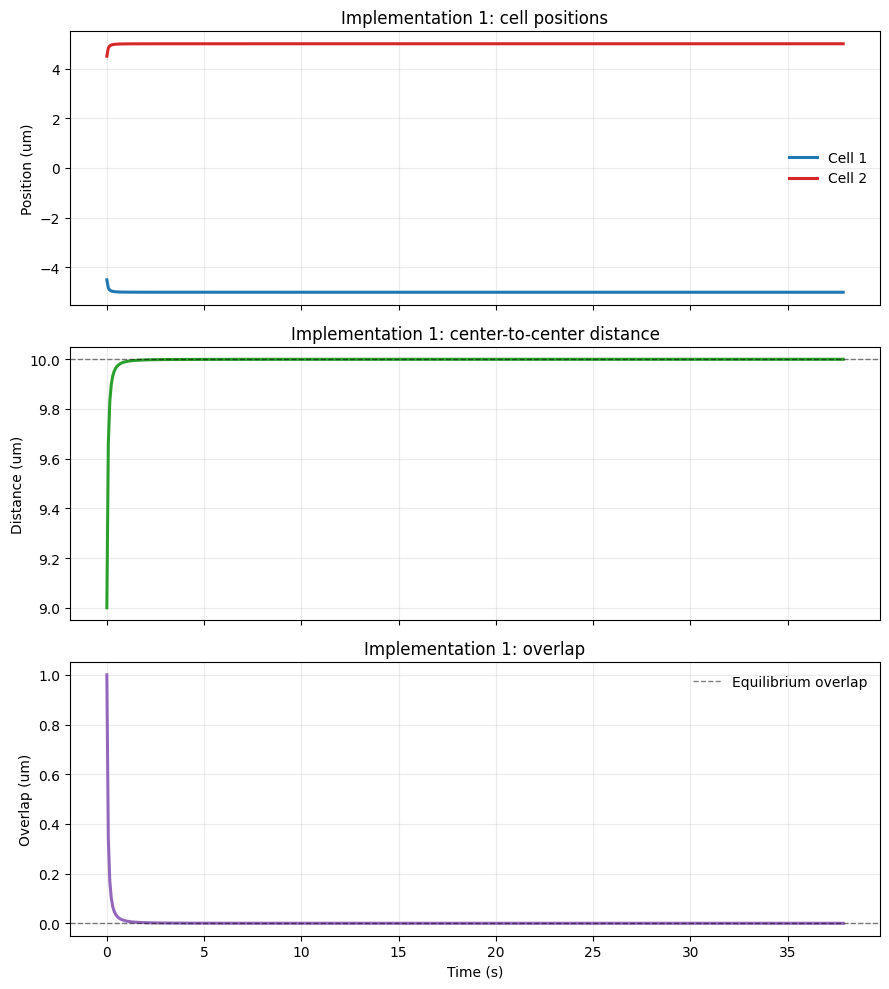

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(time_s, x1, label='Cell 1', color='#1f77b4', linewidth=2.2)
axes[0].plot(time_s, x2, label='Cell 2', color='#d62728', linewidth=2.2)
axes[0].set_ylabel('Position (um)')
axes[0].set_title('Implementation 1: cell positions')
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(time_s, distance, color='#2ca02c', linewidth=2.2)
axes[1].axhline(2.0 * R, color='black', linewidth=1.0, alpha=0.5, linestyle='--')
axes[1].set_ylabel('Distance (um)')
axes[1].set_title('Implementation 1: center-to-center distance')
axes[1].grid(True, alpha=0.25)

axes[2].plot(time_s, delta, color='#9467bd', linewidth=2.2)
axes[2].axhline(delta_eq, color='black', linewidth=1.0, alpha=0.5, linestyle='--', label='Equilibrium overlap')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Overlap (um)')
axes[2].set_title('Implementation 1: overlap')
axes[2].grid(True, alpha=0.25)
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

In [3]:
results = pd.DataFrame(
    {
        'time_s': time_s,
        'x1_um': x1,
        'x2_um': x2,
        'distance_um': distance,
        'overlap_um': delta,
        'v1_um_per_min': v1,
        'v2_um_per_min': v2,
    }
)

results.head(10)

,time_s,x1_um,x2_um,distance_um,overlap_um,v1_um_per_min,v2_um_per_min
0,0.000000,-4.500000,4.500000,9.000000,1.000000,-564.691767,564.691767
1,0.075861,-4.829797,4.829797,9.659595,0.340405,-112.151210,112.151210
2,0.151722,-4.915180,4.915180,9.830359,0.169641,-39.454783,39.454783
3,0.227582,-4.949348,4.949348,9.898697,0.101303,-18.206679,18.206679
4,0.303443,-4.966369,4.966369,9.932738,0.067262,-9.850049,9.850049
5,0.379304,-4.976056,4.976056,9.952112,0.047888,-5.916957,5.916957
6,0.455165,-4.982089,4.982089,9.964178,0.035822,-3.827839,3.827839
7,0.531025,-4.986099,4.986099,9.972198,0.027802,-2.617070,2.617070
8,0.606886,-4.988899,4.988899,9.977797,0.022203,-1.867535,1.867535
9,0.682747,-4.990930,4.990930,9.981860,0.018140,-1.378944,1.378944


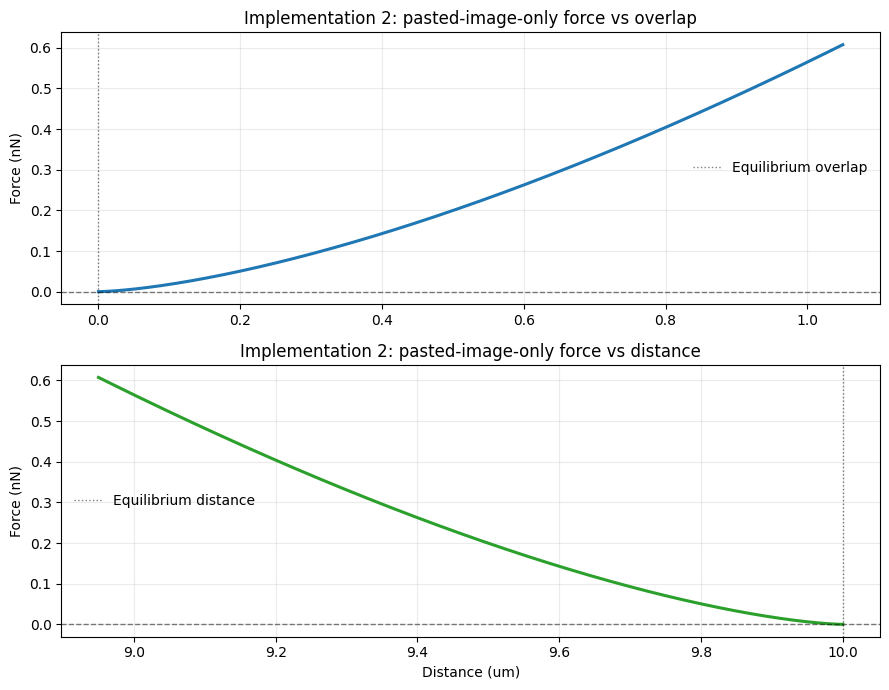

,parameter,value,units
0,gamma,8.560024e-15,J/m^2
1,delta_eq,2.420111e-07,um
2,d_eq,1.000000e+01,um


In [4]:
# Implementation 2: pasted-image-only force law (no added dynamics)

img_k_B = 1.380649e-23  # J/K
img_T_K = 310.0
img_sigma_m_per_m2 = 1.0e5
img_W_s_multiple_of_kBT = 20.0

img_R_i_um = 5.0
img_R_j_um = 5.0
img_E_i_Pa = 450.0
img_E_j_Pa = 450.0
img_nu_i = 0.4
img_nu_j = 0.4
img_delta0_um = 1.0

img_R_i_m = img_R_i_um * 1e-6
img_R_j_m = img_R_j_um * 1e-6
img_W_s_J = img_W_s_multiple_of_kBT * img_k_B * img_T_K
img_gamma_J_per_m2 = img_sigma_m_per_m2 * img_W_s_J

img_R_tilde_m = 1.0 / (1.0 / img_R_i_m + 1.0 / img_R_j_m)
img_E_tilde_Pa = 1.0 / (((1.0 - img_nu_i ** 2) / img_E_i_Pa) + ((1.0 - img_nu_j ** 2) / img_E_j_Pa))

img_A_SI = (4.0 / 3.0) * img_E_tilde_Pa * math.sqrt(img_R_tilde_m)
img_B_SI = math.pi * img_gamma_J_per_m2 * img_R_tilde_m
img_delta_eq_m = (img_B_SI / img_A_SI) ** (2.0 / 3.0)
img_delta_eq_um = img_delta_eq_m * 1e6
img_d_eq_um = img_R_i_um + img_R_j_um - img_delta_eq_um

def img_extended_hertz_force_N(overlap_um):
    overlap_m = np.maximum(np.asarray(overlap_um, dtype=float), 0.0) * 1e-6
    return img_A_SI * overlap_m ** 1.5 - img_B_SI

img_overlap_grid_um = np.linspace(0.0, max(1.05 * img_delta0_um, 1e-6), 500)
img_distance_grid_um = img_R_i_um + img_R_j_um - img_overlap_grid_um
img_force_grid_N = img_extended_hertz_force_N(img_overlap_grid_um)
img_force_grid_nN = img_force_grid_N * 1e9

img_summary = pd.DataFrame(
    {
        'parameter': ['gamma', 'delta_eq', 'd_eq'],
        'value': [img_gamma_J_per_m2, img_delta_eq_um, img_d_eq_um],
        'units': ['J/m^2', 'um', 'um'],
    }
)

fig_img, axes_img = plt.subplots(2, 1, figsize=(9, 7), sharex=False)
axes_img[0].plot(img_overlap_grid_um, img_force_grid_nN, color='#1f77b4', linewidth=2.2)
axes_img[0].axhline(0.0, color='black', linewidth=1.0, alpha=0.5, linestyle='--')
axes_img[0].axvline(img_delta_eq_um, color='black', linewidth=1.0, alpha=0.5, linestyle=':', label='Equilibrium overlap')
axes_img[0].set_ylabel('Force (nN)')
axes_img[0].set_title('Implementation 2: pasted-image-only force vs overlap')
axes_img[0].grid(True, alpha=0.25)
axes_img[0].legend(frameon=False)

axes_img[1].plot(img_distance_grid_um, img_force_grid_nN, color='#2ca02c', linewidth=2.2)
axes_img[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.5, linestyle='--')
axes_img[1].axvline(img_d_eq_um, color='black', linewidth=1.0, alpha=0.5, linestyle=':', label='Equilibrium distance')
axes_img[1].set_xlabel('Distance (um)')
axes_img[1].set_ylabel('Force (nN)')
axes_img[1].set_title('Implementation 2: pasted-image-only force vs distance')
axes_img[1].grid(True, alpha=0.25)
axes_img[1].legend(frameon=False)

plt.tight_layout()
plt.show()

img_summary

## PhysiCell simulation analysis



This section analyzes the PhysiCell simulation outputs stored in `PhysiCell/results/mechanics_pushing_extended_hertz`.



The plots below are separate from the analytical plots above. They use the saved PhysiCell snapshots to reconstruct the two-cell trajectories, the center-to-center distance, and the geometric overlap over time.



For the simulation analysis, the geometric overlap is computed as



$$

\delta_{\mathrm{sim}} = \max(0, 2R - d),

$$



so once the cells fully detach the overlap is reported as zero.


In [5]:
from pathlib import Path

import sys



repo_root = Path.cwd().resolve().parent.parent

simulation_dir = repo_root / 'PhysiCell' / 'results' / 'mechanics_pushing_extended_hertz'

pymcds_dir = repo_root / 'PhysiCell' / 'code' / 'studio' / 'bin'



if str(pymcds_dir) not in sys.path:

    sys.path.insert(0, str(pymcds_dir))



from pyMCDS import pyMCDS



simulation_rows = []

for xml_path in sorted(simulation_dir.glob('output*.xml')):

    mcds = pyMCDS(xml_path.name, str(simulation_dir), microenv=False, graph=False, verbose=False)

    cell_df = mcds.get_cell_df().reset_index().sort_values('ID').reset_index(drop=True)

    if len(cell_df) < 2:

        continue

    x_left = float(cell_df.loc[0, 'position_x'])

    x_right = float(cell_df.loc[1, 'position_x'])

    radius_sim = float(cell_df.loc[0, 'radius'])

    distance_sim = abs(x_right - x_left)

    overlap_sim = max(0.0, 2.0 * radius_sim - distance_sim)

    simulation_rows.append(

        {

            'time_min': float(mcds.get_time()),

            'time_s': 60.0 * float(mcds.get_time()),

            'x1_um': x_left,

            'x2_um': x_right,

            'distance_um': distance_sim,

            'overlap_um': overlap_sim,

            'radius_um': radius_sim,

        }

    )



simulation_results = pd.DataFrame(simulation_rows).sort_values('time_min').reset_index(drop=True)

simulation_results.head(10)


,time_min,time_s,x1_um,x2_um,distance_um,overlap_um,radius_um
0,0.0,0.0,-4.500000,4.500000,9.000000,1.000008,5.000004
1,0.1,6.0,-4.490316,4.490316,8.980632,1.019376,5.000004
2,0.2,12.0,-4.485343,4.485343,8.970687,1.029321,5.000004
3,0.3,18.0,-4.480644,4.480644,8.961287,1.038721,5.000004
4,0.4,24.0,-4.476417,4.476417,8.952834,1.047174,5.000004
5,0.5,30.0,-4.472605,4.472605,8.945210,1.054797,5.000004
6,0.6,36.0,-4.469170,4.469170,8.938340,1.061668,5.000004
7,0.7,42.0,-4.466075,4.466075,8.932150,1.067858,5.000004
8,0.8,48.0,-4.463287,4.463287,8.926575,1.073433,5.000004
9,0.9,54.0,-4.460777,4.460777,8.921554,1.078453,5.000004


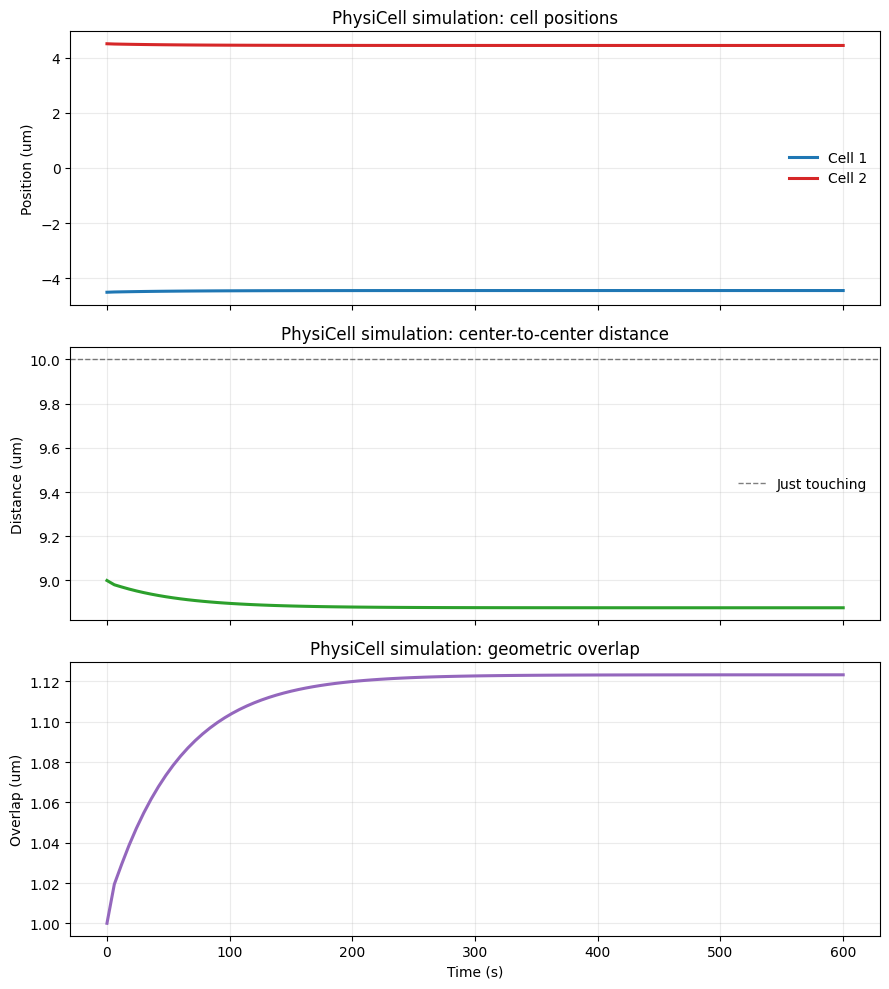

In [6]:
fig_sim, axes_sim = plt.subplots(3, 1, figsize=(9, 10), sharex=True)



axes_sim[0].plot(simulation_results['time_s'], simulation_results['x1_um'], label='Cell 1', color='#1f77b4', linewidth=2.2)

axes_sim[0].plot(simulation_results['time_s'], simulation_results['x2_um'], label='Cell 2', color='#d62728', linewidth=2.2)

axes_sim[0].set_ylabel('Position (um)')

axes_sim[0].set_title('PhysiCell simulation: cell positions')

axes_sim[0].grid(True, alpha=0.25)

axes_sim[0].legend(frameon=False)



axes_sim[1].plot(simulation_results['time_s'], simulation_results['distance_um'], color='#2ca02c', linewidth=2.2)

axes_sim[1].axhline(2.0 * simulation_results['radius_um'].iloc[0], color='black', linewidth=1.0, alpha=0.5, linestyle='--', label='Just touching')

axes_sim[1].set_ylabel('Distance (um)')

axes_sim[1].set_title('PhysiCell simulation: center-to-center distance')

axes_sim[1].grid(True, alpha=0.25)

axes_sim[1].legend(frameon=False)



axes_sim[2].plot(simulation_results['time_s'], simulation_results['overlap_um'], color='#9467bd', linewidth=2.2)

axes_sim[2].set_xlabel('Time (s)')

axes_sim[2].set_ylabel('Overlap (um)')

axes_sim[2].set_title('PhysiCell simulation: geometric overlap')

axes_sim[2].grid(True, alpha=0.25)



plt.tight_layout()

plt.show()


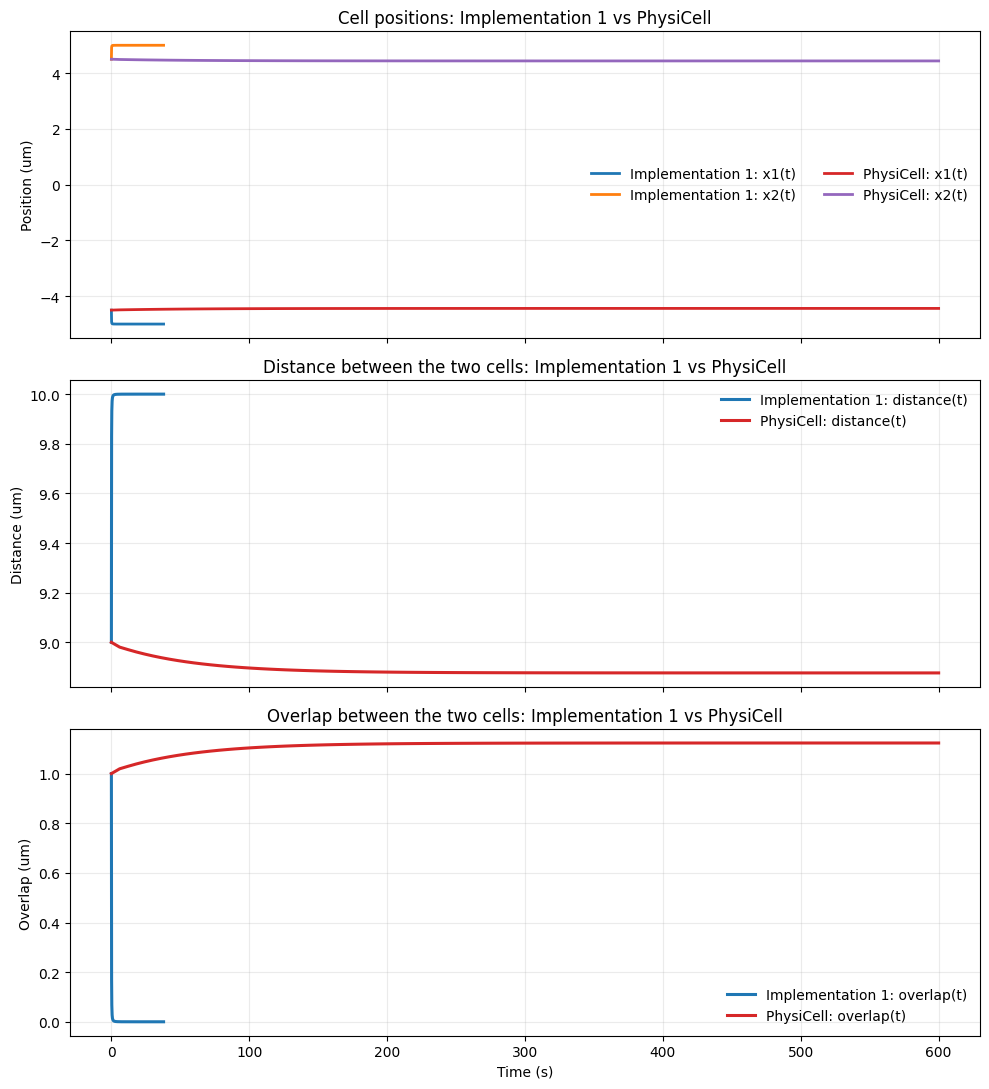

,implementation,reference_distance_um,reference_overlap_um,reference_x1_um,reference_x2_um,description
0,Implementation 1: current C++-matched native m...,9.999888,0.000112,-4.999944,4.999944,Final state from the current analytical trajec...
1,Implementation 3: PhysiCell simulation,8.876696,1.123312,-4.438348,4.438348,Last saved state from the PhysiCell simulation...


In [7]:
distance_comparison = pd.DataFrame(
    {
        'implementation': [
            'Implementation 1: current C++-matched native mapping',
            'Implementation 3: PhysiCell simulation',
        ],
        'reference_distance_um': [
            float(distance[-1]),
            float(simulation_results['distance_um'].iloc[-1]),
        ],
        'reference_overlap_um': [
            float(delta[-1]),
            float(simulation_results['overlap_um'].iloc[-1]),
        ],
        'reference_x1_um': [
            float(x1[-1]),
            float(simulation_results['x1_um'].iloc[-1]),
        ],
        'reference_x2_um': [
            float(x2[-1]),
            float(simulation_results['x2_um'].iloc[-1]),
        ],
        'description': [
            'Final state from the current analytical trajectory in native PhysiCell units',
            'Last saved state from the PhysiCell simulation outputs',
        ],
    }
)

fig_compare, axes_compare = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

axes_compare[0].plot(time_s, x1, color='#1f77b4', linewidth=2.0, label='Implementation 1: x1(t)')
axes_compare[0].plot(time_s, x2, color='#ff7f0e', linewidth=2.0, label='Implementation 1: x2(t)')
axes_compare[0].plot(simulation_results['time_s'], simulation_results['x1_um'], color='#d62728', linewidth=2.0, label='PhysiCell: x1(t)')
axes_compare[0].plot(simulation_results['time_s'], simulation_results['x2_um'], color='#9467bd', linewidth=2.0, label='PhysiCell: x2(t)')
axes_compare[0].set_ylabel('Position (um)')
axes_compare[0].set_title('Cell positions: Implementation 1 vs PhysiCell')
axes_compare[0].grid(True, alpha=0.25)
axes_compare[0].legend(frameon=False, ncol=2)

axes_compare[1].plot(time_s, distance, color='#1f77b4', linewidth=2.2, label='Implementation 1: distance(t)')
axes_compare[1].plot(simulation_results['time_s'], simulation_results['distance_um'], color='#d62728', linewidth=2.2, label='PhysiCell: distance(t)')
axes_compare[1].set_ylabel('Distance (um)')
axes_compare[1].set_title('Distance between the two cells: Implementation 1 vs PhysiCell')
axes_compare[1].grid(True, alpha=0.25)
axes_compare[1].legend(frameon=False)

axes_compare[2].plot(time_s, delta, color='#1f77b4', linewidth=2.2, label='Implementation 1: overlap(t)')
axes_compare[2].plot(simulation_results['time_s'], simulation_results['overlap_um'], color='#d62728', linewidth=2.2, label='PhysiCell: overlap(t)')
axes_compare[2].set_xlabel('Time (s)')
axes_compare[2].set_ylabel('Overlap (um)')
axes_compare[2].set_title('Overlap between the two cells: Implementation 1 vs PhysiCell')
axes_compare[2].grid(True, alpha=0.25)
axes_compare[2].legend(frameon=False)

plt.tight_layout()
plt.show()

distance_comparison